In [12]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from sometria.catalog import (
    MotionViewSpec,
    build_motion_view,
    create_pretrain_split,
    load_annotations,
    load_catalog,
    load_label_vocabulary,
    load_splits,
    normalization_path,
)
from sometria.preprocess import ImportConfig, import_opensim_csv_dataset
from sometria.babel import (
    import_babel_splits,
    import_babel_annotations,
    import_babel_action_vocabulary,
)
from sometria.normalization import save_feature_normalization
from sometria.representation import Representation, _load_human_definition


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
RAW_MOTIONX = Path("/home/z1ko/datasets/sometria/motionx")
OUT = Path("../data/processed")

# the representation carries its own name, so the stats path and the catalog column
# cannot drift from the encoding that actually produced the tensors
HUMAN = _load_human_definition("/home/z1ko/develop/sometria/config/human.yaml")
REPRESENTATION = Representation.from_human(HUMAN)
NORMALIZATION_NAME = "pretrain_v2_train_clean"
# catalog owns the layout; nothing outside it should spell out stats/<representation>/<name>.pt
NORMALIZATION_PATH = normalization_path(OUT, REPRESENTATION.name, NORMALIZATION_NAME)
print(REPRESENTATION)


Representation('opensim_sincos_log_vel_acc_tau_v2', 43 dofs, 5 channels)


In [ ]:
catalog = import_opensim_csv_dataset(
    config=ImportConfig(
        source_dataset="MotionX",
        input_root=RAW_MOTIONX,
        output_root=OUT,
        pattern="**/*.csv"
    ),
    representation=REPRESENTATION,
    human=HUMAN,
)

pretrain = create_pretrain_split(output_root=OUT, split_set="pretrain_v2", source_datasets=("AMASS", "MotionX"))
print(f"{len(catalog):,} samples")
catalog.head()

100%|██████████| 88638/88638 [31:46<00:00, 46.48it/s] 


106,091 samples


sample_id,source_dataset,source_subset,source_path,motion_path,representation,metadata,hz,original_hz,n_frames,duration,tau_rate,tau_absmax,nonfinite,broken,n_dofs,n_features
str,str,str,str,str,str,struct[2],f64,f64,i64,f64,f64,f64,bool,bool,i64,i64
"""AMASS:GRAB/s5/waterbottle_pick…","""AMASS""","""GRAB""","""GRAB/s5/waterbottle_pick_all_s…","""motions/amass/8f00b30728fb16a2…","""opensim_sincos_log_vel_acc_tau…","{1.727507,65.654133}",60.0,120.048019,944,15.733333,10583.242404,703.466801,false,false,43,5
"""MotionX:game_motion/subset_001…","""MotionX""","""game_motion""","""game_motion/subset_0016/Katana…","""motions/motionx/bf4f3ad6e7f080…","""opensim_sincos_log_vel_acc_tau…","{1.71888,65.000097}",60.0,30.535284,111,1.85,3.5371e6,63493.269055,false,true,43,5
"""MotionX:motionx/fitness/subset…","""MotionX""","""motionx""","""motionx/fitness/subset_0012/Si…","""motions/motionx/90f13e69f44a6c…","""opensim_sincos_log_vel_acc_tau…","{1.71888,65.000097}",60.0,30.102348,600,10.0,75084.749785,1880.896218,false,false,43,5
"""MotionX:game_motion/subset_000…","""MotionX""","""game_motion""","""game_motion/subset_0003/Dual_W…","""motions/motionx/474036900eac7c…","""opensim_sincos_log_vel_acc_tau…","{1.71888,65.000097}",60.0,30.202356,294,4.9,1.6573e6,20003.286211,false,true,43,5
"""MotionX:fitness/subset_0035/Si…","""MotionX""","""fitness""","""fitness/subset_0035/Side_Stret…","""motions/motionx/0564c75f9bf3d8…","""opensim_sincos_log_vel_acc_tau…","{1.71888,65.000097}",60.0,30.525962,113,1.883333,3.6073e6,53839.533604,false,true,43,5


## Normalization


In [14]:
train_samples = build_motion_view(
    OUT,
    MotionViewSpec(
        split_set="pretrain_v2",
        split="train",
        source_datasets=("AMASS","MotionX"),
        exclude_broken=True,
        min_frames=240
    )
)

stats_path = save_feature_normalization(
    output_root=OUT,
    samples=train_samples,
    name=NORMALIZATION_NAME,
    representation=REPRESENTATION,
    split_set="pretrain_v2",
    split="train",
)

stats_path

100%|██████████| 34887/34887 [00:41<00:00, 848.11it/s]


PosixPath('../data/processed/stats/opensim_sincos_log_vel_acc_tau_v2/pretrain_v2_train_clean.pt')

In [15]:
import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                   
import numpy as np                                                                                                                                                                                                                                                                                
import polars as pl                                                                                                                                                                                                                                                                               
import torch as t                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                     
catalog = load_catalog(OUT)                                                                                                                                                                                                                                                                       
splits = load_splits(OUT) 

### Torque quality

`measure_quality` runs on the raw OpenSim channels before `Representation.encode`, so `tau_rate` and `tau_absmax` below stay in physical units, unaffected by the signed-log transform. That is deliberate: discontinuity detection belongs in real torque units, not compressed ones.


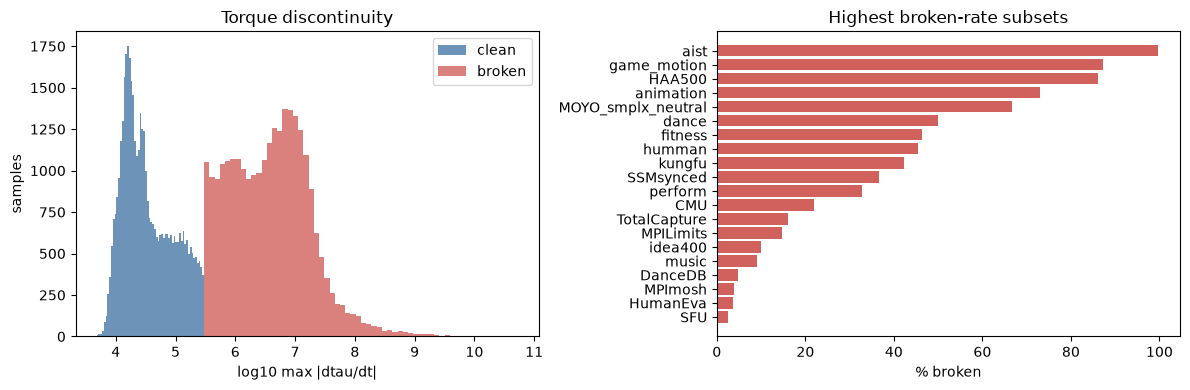

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

clean_catalog = catalog.filter(~pl.col("broken"))
broken_catalog = catalog.filter(pl.col("broken"))

ax[0].hist(np.log10(clean_catalog["tau_rate"].to_numpy().clip(1)), bins=60, alpha=0.8, color="#4878a8", label="clean")
ax[0].hist(np.log10(broken_catalog["tau_rate"].to_numpy().clip(1)), bins=60, alpha=0.8, color="#d1615d", label="broken")
ax[0].set(xlabel="log10 max |dtau/dt|", ylabel="samples", title="Torque discontinuity")
ax[0].legend()

bad_by_subset = (
    catalog
    .group_by("source_subset")
    .agg(pl.len().alias("n"), pl.col("broken").sum().alias("bad"))
    .with_columns((100 * pl.col("bad") / pl.col("n")).alias("bad_pct"))
    .sort("bad_pct", descending=True)
    .head(20)
    .sort("bad_pct")
)

ax[1].barh(bad_by_subset["source_subset"], bad_by_subset["bad_pct"], color="#d1615d")
ax[1].set(xlabel="% broken", title="Highest broken-rate subsets")

fig.tight_layout()

### What each training view sees

shape: (4, 5)
┌─────────────┬─────────┬───────────────┬───────────┬─────────────┐
│ view        ┆ samples ┆ clean_samples ┆ hours     ┆ clean_hours │
│ ---         ┆ ---     ┆ ---           ┆ ---       ┆ ---         │
│ str         ┆ i64     ┆ i64           ┆ f64       ┆ f64         │
╞═════════════╪═════════╪═══════════════╪═══════════╪═════════════╡
│ pretrain_v2 ┆ 65648   ┆ 39609         ┆ 117.40329 ┆ 89.466156   │
│ babel train ┆ 6391    ┆ 6122          ┆ 14.445967 ┆ 13.568507   │
│ babel val   ┆ 2101    ┆ 2006          ┆ 5.045773  ┆ 4.74902     │
│ babel test  ┆ 1995    ┆ 1916          ┆ 4.661786  ┆ 4.388782    │
└─────────────┴─────────┴───────────────┴───────────┴─────────────┘


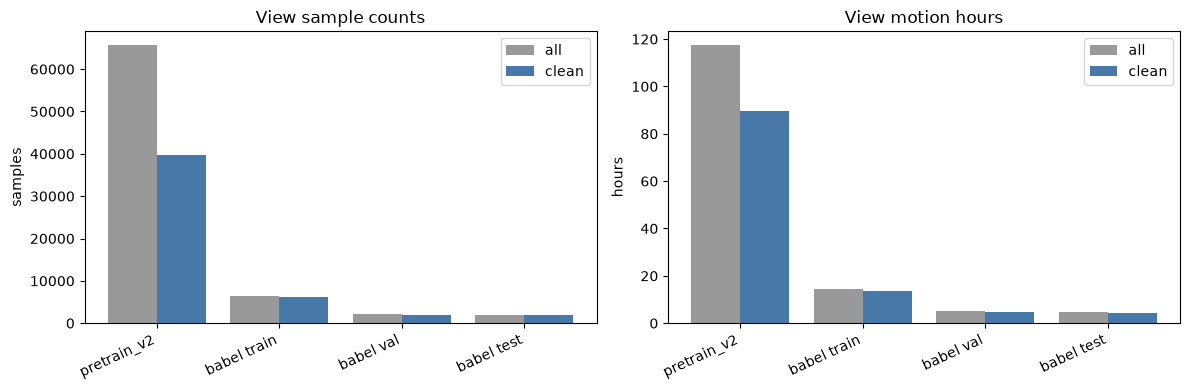

In [18]:
def split_ids(split_set: str, split: str) -> list[str]:
    return (
        splits
        .filter((pl.col("split_set") == split_set) & (pl.col("split") == split))
        .select("sample_id")
        .unique()
        .get_column("sample_id")
        .to_list()
    )

views = {
    "pretrain_v2": split_ids("pretrain_v2", "train"),
    "babel train": split_ids("babel_official", "train"),
    "babel val": split_ids("babel_official", "val"),
    "babel test": split_ids("babel_official", "test"),
}

rows = []
for name, ids in views.items():
    view = catalog.filter(pl.col("sample_id").is_in(ids))
    clean_view = view.filter(~pl.col("broken"))
    rows.append({
        "view": name,
        "samples": len(view),
        "clean_samples": len(clean_view),
        "hours": view["duration"].sum() / 3600,
        "clean_hours": clean_view["duration"].sum() / 3600,
    })

view_df = pl.DataFrame(rows)
print(view_df)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(view_df))

ax[0].bar(x - 0.2, view_df["samples"], width=0.4, label="all", color="#999999")
ax[0].bar(x + 0.2, view_df["clean_samples"], width=0.4, label="clean", color="#4878a8")
ax[0].set_xticks(x, view_df["view"], rotation=25, ha="right")
ax[0].set(title="View sample counts", ylabel="samples")
ax[0].legend()

ax[1].bar(x - 0.2, view_df["hours"], width=0.4, label="all", color="#999999")
ax[1].bar(x + 0.2, view_df["clean_hours"], width=0.4, label="clean", color="#4878a8")
ax[1].set_xticks(x, view_df["view"], rotation=25, ha="right")
ax[1].set(title="View motion hours", ylabel="hours")
ax[1].legend()

fig.tight_layout()

### Normalization stats


mean shape: (43, 5)
std shape:  (43, 5)
normalized channels: ['vel', 'acc', 'tau']
pass-through channels: ['sin', 'cos']


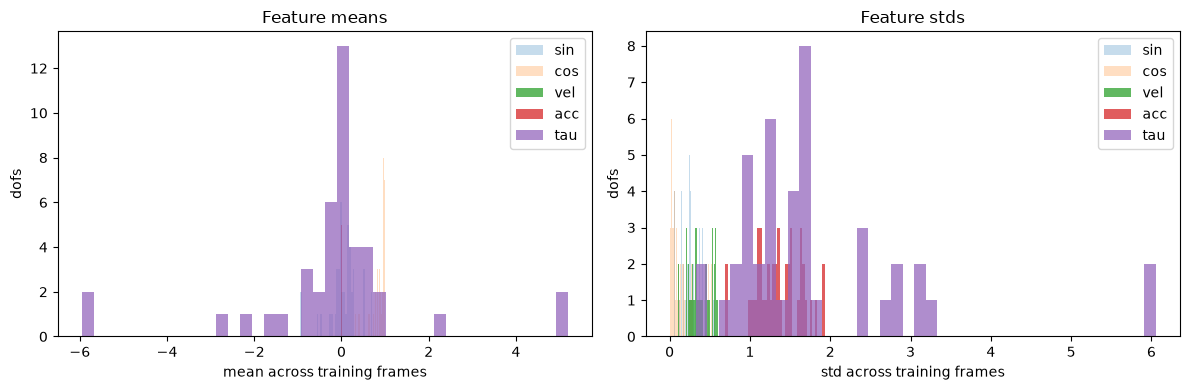

In [8]:
stats = t.load(NORMALIZATION_PATH, weights_only=True)
mean = stats["mean"].squeeze(0).numpy()
std = stats["std"].squeeze(0).numpy()

feature_names = list(REPRESENTATION.channels)
# sin/cos are bounded in [-1, 1] and encode circular geometry, so the representation
# passes them through untouched; the stats below only apply to the other three
passthrough = set(REPRESENTATION.indices("sin", "cos"))

print(f"mean shape: {mean.shape}")
print(f"std shape:  {std.shape}")
print("normalized channels:", [n for i, n in enumerate(feature_names) if i not in passthrough])
print("pass-through channels:", [n for i, n in enumerate(feature_names) if i in passthrough])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for channel, name in enumerate(feature_names):
    alpha = 0.25 if channel in passthrough else 0.75
    ax[0].hist(mean[:, channel], bins=40, alpha=alpha, label=name)
    ax[1].hist(std[:, channel], bins=40, alpha=alpha, label=name)

ax[0].set(title="Feature means", xlabel="mean across training frames", ylabel="dofs")
ax[1].set(title="Feature stds", xlabel="std across training frames", ylabel="dofs")
ax[0].legend()
ax[1].legend()

fig.tight_layout()


### Normalization effect on feature distributions


preview samples: 24
preview frames: 10,964


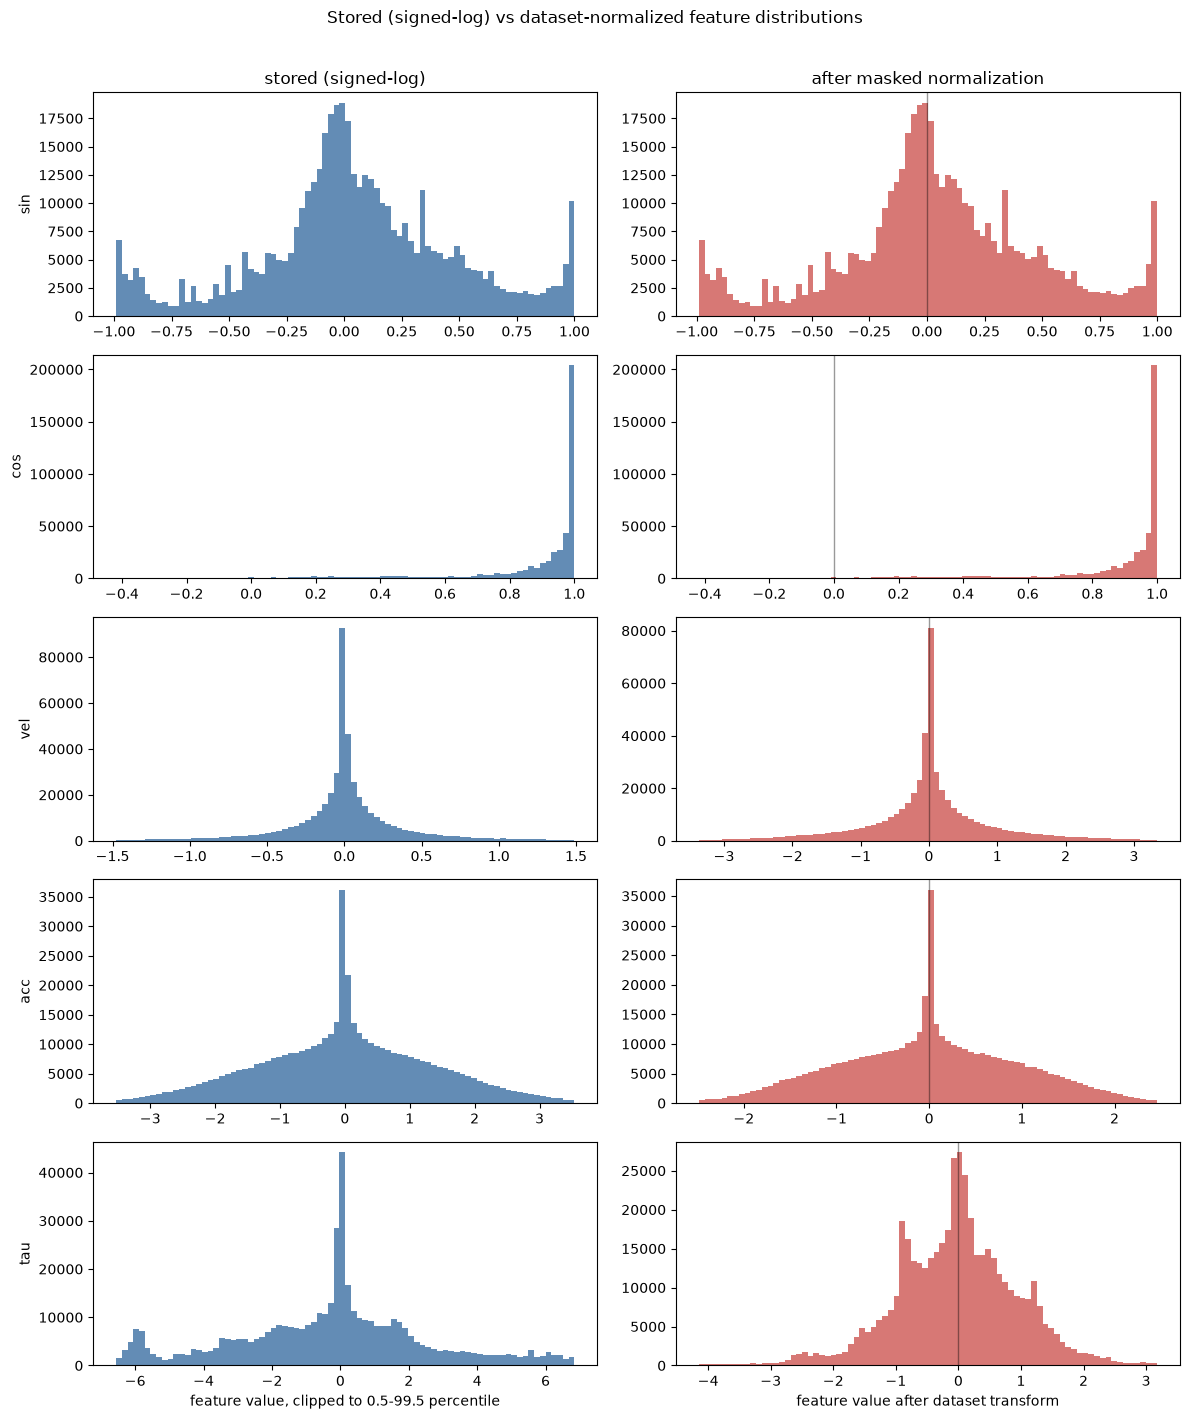

In [9]:
stats = t.load(NORMALIZATION_PATH, weights_only=True)
train_samples = build_motion_view(
    OUT,
    MotionViewSpec(
        split_set="pretrain_v2",
        split="train",
        source_datasets=("AMASS", "MotionX"),
        exclude_broken=True,
    )
)

preview_n = min(24, len(train_samples))
preview_samples = train_samples.sample(n=preview_n, seed=7) if preview_n else train_samples

stored_chunks = []
normalized_chunks = []
for row in preview_samples.iter_rows(named=True):
    payload = t.load(OUT / row["motion_path"], weights_only=True)
    features = payload["features"].float()
    normalized = REPRESENTATION.to_model(features, stats)

    step = max(1, features.shape[0] // 800)
    stored_chunks.append(features[::step])
    normalized_chunks.append(normalized[::step])

stored_preview = t.cat(stored_chunks, dim=0).numpy()
normalized_preview = t.cat(normalized_chunks, dim=0).numpy()

print(f"preview samples: {preview_n}")
print(f"preview frames: {stored_preview.shape[0]:,}")

fig, ax = plt.subplots(len(feature_names), 2, figsize=(12, 14))

for channel, name in enumerate(feature_names):
    stored_values = stored_preview[:, :, channel].reshape(-1)
    normalized_values = normalized_preview[:, :, channel].reshape(-1)

    stored_lo, stored_hi = np.percentile(stored_values, [0.5, 99.5])
    norm_lo, norm_hi = np.percentile(normalized_values, [0.5, 99.5])

    ax[channel, 0].hist(stored_values, bins=80, range=(stored_lo, stored_hi), color="#4878a8", alpha=0.85)
    ax[channel, 1].hist(normalized_values, bins=80, range=(norm_lo, norm_hi), color="#d1615d", alpha=0.85)

    ax[channel, 0].set_ylabel(name)
    ax[channel, 0].set_title("stored (signed-log)" if channel == 0 else "")
    ax[channel, 1].set_title("after masked normalization" if channel == 0 else "")
    ax[channel, 1].axvline(0, color="black", linewidth=1, alpha=0.4)

ax[-1, 0].set_xlabel("feature value, clipped to 0.5-99.5 percentile")
ax[-1, 1].set_xlabel("feature value after dataset transform")
fig.suptitle("Stored (signed-log) vs dataset-normalized feature distributions", y=1.01)
fig.tight_layout()


### Normalization summary on preview samples


shape: (5, 7)
┌─────────┬─────────────┬────────────┬────────────┬───────────┬───────────┬───────────┐
│ feature ┆ stored_mean ┆ stored_std ┆ after_mean ┆ after_std ┆ after_p01 ┆ after_p99 │
│ ---     ┆ ---         ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│ str     ┆ f64         ┆ f64        ┆ f64        ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪═════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ sin     ┆ 0.046       ┆ 0.445      ┆ 0.046      ┆ 0.445     ┆ -0.983    ┆ 0.996     │
│ cos     ┆ 0.852       ┆ 0.271      ┆ 0.852      ┆ 0.271     ┆ -0.28     ┆ 1.0       │
│ vel     ┆ -0.001      ┆ 0.405      ┆ -0.003     ┆ 0.997     ┆ -2.914    ┆ 2.913     │
│ acc     ┆ 0.001       ┆ 1.368      ┆ -0.0       ┆ 0.984     ┆ -2.253    ┆ 2.239     │
│ tau     ┆ -0.251      ┆ 2.874      ┆ -0.045     ┆ 1.081     ┆ -3.114    ┆ 2.538     │
└─────────┴─────────────┴────────────┴────────────┴───────────┴───────────┴───────────┘


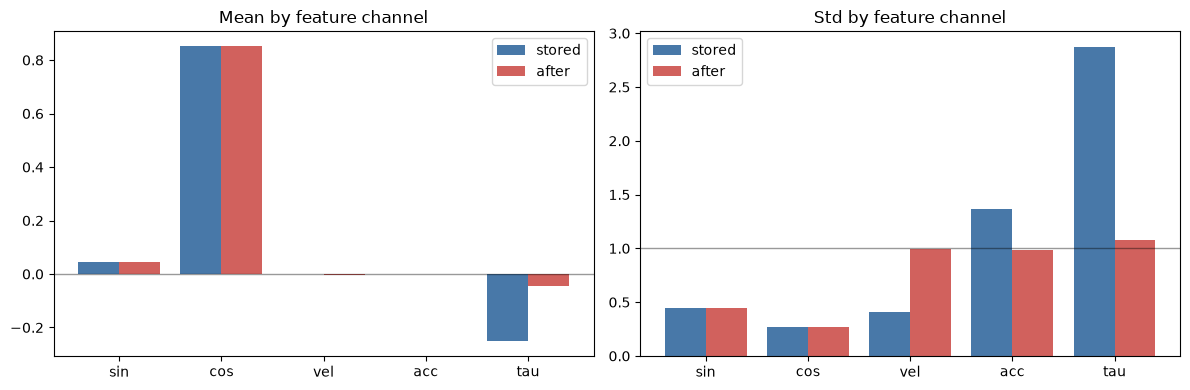

In [10]:
rows = []
for channel, name in enumerate(feature_names):
    stored_values = stored_preview[:, :, channel].reshape(-1)
    normalized_values = normalized_preview[:, :, channel].reshape(-1)
    rows.append({
        "feature": name,
        "stored_mean": stored_values.mean(),
        "stored_std": stored_values.std(),
        "after_mean": normalized_values.mean(),
        "after_std": normalized_values.std(),
        "after_p01": np.percentile(normalized_values, 1),
        "after_p99": np.percentile(normalized_values, 99),
    })

normalization_effect = pl.DataFrame(rows)
print(normalization_effect.with_columns(pl.all().exclude("feature").round(3)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(feature_names))

ax[0].bar(x - 0.2, normalization_effect["stored_mean"], width=0.4, label="stored", color="#4878a8")
ax[0].bar(x + 0.2, normalization_effect["after_mean"], width=0.4, label="after", color="#d1615d")
ax[0].axhline(0, color="black", linewidth=1, alpha=0.4)
ax[0].set_xticks(x, feature_names)
ax[0].set_title("Mean by feature channel")
ax[0].legend()

ax[1].bar(x - 0.2, normalization_effect["stored_std"], width=0.4, label="stored", color="#4878a8")
ax[1].bar(x + 0.2, normalization_effect["after_std"], width=0.4, label="after", color="#d1615d")
ax[1].axhline(1, color="black", linewidth=1, alpha=0.4)
ax[1].set_xticks(x, feature_names)
ax[1].set_title("Std by feature channel")
ax[1].legend()

fig.tight_layout()


### Normalization effect on one motion


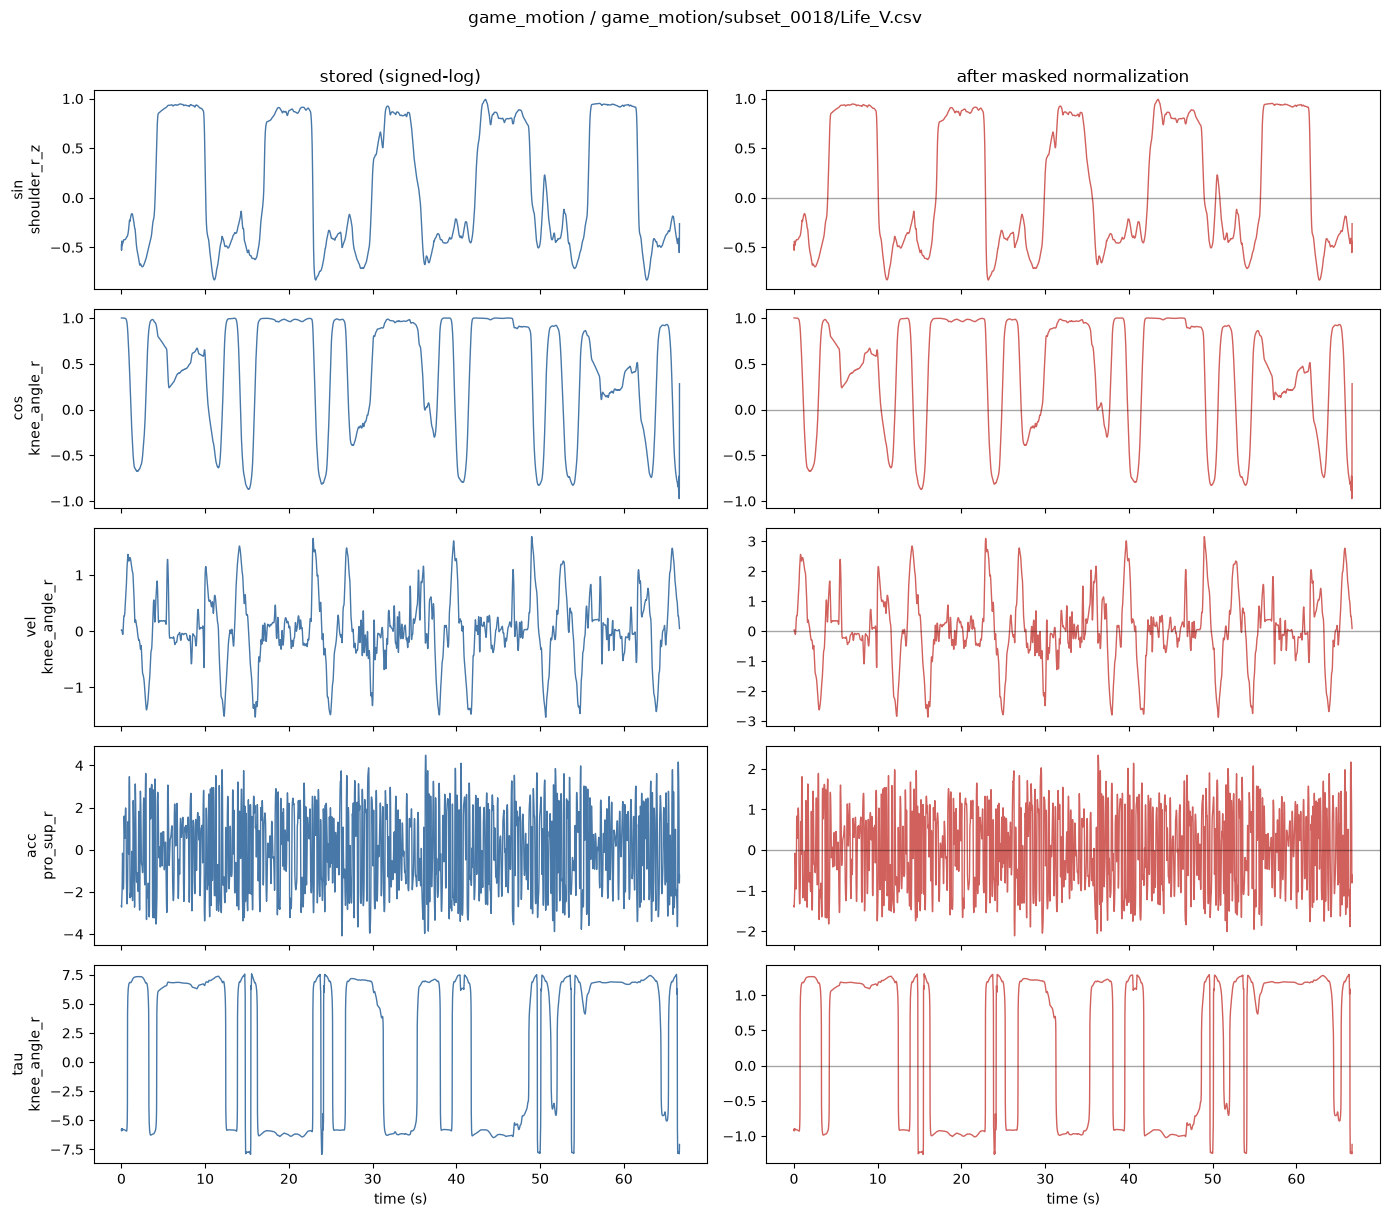

In [11]:
example = train_samples.sort("duration", descending=True).row(0, named=True)
payload = t.load(OUT / example["motion_path"], weights_only=True)
features = payload["features"].float()
normalized = REPRESENTATION.to_model(features, stats)
time = payload["time"].numpy()
dof_names = REPRESENTATION.dofs

fig, ax = plt.subplots(len(feature_names), 2, figsize=(14, 12), sharex=True)

for channel, name in enumerate(feature_names):
    dof = int(features[:, :, channel].std(dim=0).argmax())
    stored_series = features[:, dof, channel].numpy()
    normalized_series = normalized[:, dof, channel].numpy()

    ax[channel, 0].plot(time, stored_series, color="#4878a8", linewidth=1)
    ax[channel, 1].plot(time, normalized_series, color="#d1615d", linewidth=1)
    ax[channel, 1].axhline(0, color="black", linewidth=1, alpha=0.35)

    ax[channel, 0].set_ylabel(f"{name}\n{dof_names[dof]}")
    ax[channel, 0].set_title("stored (signed-log)" if channel == 0 else "")
    ax[channel, 1].set_title("after masked normalization" if channel == 0 else "")

ax[-1, 0].set_xlabel("time (s)")
ax[-1, 1].set_xlabel("time (s)")
fig.suptitle(f"{example['source_subset']} / {example['source_path']}", y=1.01)
fig.tight_layout()
